In [1]:
import numpy as np
import pandas as pd

from sklearn.datasets import fetch_california_housing

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
housing = fetch_california_housing()

In [3]:
print(housing.keys())

dict_keys(['data', 'target', 'frame', 'target_names', 'feature_names', 'DESCR'])


In [4]:
df = pd.DataFrame(
    housing.data,
    columns=housing.feature_names
)

In [5]:
df["MedHouseVal"] = housing.target

In [6]:
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [7]:
df.shape

(20640, 9)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


Dataset Inspection: The California Housing dataset contains 20,640 observations and 9 numerical columns. All columns contain 20,640 non-null values, indicating that there are no missing values. Since all variables are numerical, no categorical encoding is required.

In [9]:
df.isnull().sum()

MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

Missing Value Handling: Missing values were checked using isnull().sum(). All columns contained zero missing values, so no imputation or removal of observations was necessary.

In [10]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [11]:
X = df.drop("MedHouseVal", axis=1)
y = df["MedHouseVal"]

In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [13]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [14]:
X = df.drop("MedHouseVal", axis=1)
y = df["MedHouseVal"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (20640, 8)
Target shape: (20640,)


In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (16512, 8)
X_test: (4128, 8)
y_train: (16512,)
y_test: (4128,)


## Linear Regression

Linear Regression is a supervised learning algorithm that models the relationship between the input features and the target variable using a linear equation. It finds the best-fitting line by minimizing the difference between the actual and predicted values.

It is suitable for the California Housing dataset because it provides a simple baseline model for predicting median house values. It is also useful for understanding how well a linear relationship can represent the dataset.


In [16]:
#Linear Regession
from sklearn.linear_model import LinearRegression

In [17]:
lr_model = LinearRegression()

In [18]:
lr_model.fit(X_train_scaled, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [19]:
y_pred_lr = lr_model.predict(X_test_scaled)

In [20]:
print(y_pred_lr[:10])

[0.71912284 1.76401657 2.70965883 2.83892593 2.60465725 2.01175367
 2.64550005 2.16875532 2.74074644 3.91561473]


In [21]:
print(y_test[:10].values)

[0.477   0.458   5.00001 2.186   2.78    1.587   1.982   1.575   3.4
 4.466  ]


In [22]:
print("Predicted:", y_pred_lr[:10])
print("Actual:   ", y_test.iloc[:10].values)

Predicted: [0.71912284 1.76401657 2.70965883 2.83892593 2.60465725 2.01175367
 2.64550005 2.16875532 2.74074644 3.91561473]
Actual:    [0.477   0.458   5.00001 2.186   2.78    1.587   1.982   1.575   3.4
 4.466  ]


In [23]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [24]:
mse_lr = mean_squared_error(y_test, y_pred_lr)
mae_lr = mean_absolute_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)

In [25]:
print("Linear Regression")
print("MSE:", mse_lr)
print("MAE:", mae_lr)
print("R² Score:", r2_lr)

Linear Regression
MSE: 0.5558915986952442
MAE: 0.5332001304956566
R² Score: 0.575787706032451


In [26]:
results = {
    "Linear Regression": {
        "MSE": mse_lr,
        "MAE": mae_lr,
        "R2": r2_lr
    }
}

## Decision Tree Regressor

A Decision Tree Regressor predicts a continuous target value by repeatedly splitting the data into smaller groups based on feature values. The final prediction is generally based on the target values of the samples within the resulting leaf node.

It is suitable for the California Housing dataset because it can capture nonlinear relationships and interactions between housing features without requiring the data to follow a linear pattern. It also does not require feature scaling.


In [27]:
#Decision Tree Regressor
from sklearn.tree import DecisionTreeRegressor

In [28]:
dt_model = DecisionTreeRegressor(random_state=42)

In [29]:
dt_model.fit(X_train, y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [30]:
y_pred_dt = dt_model.predict(X_test)

In [31]:
mse_dt = mean_squared_error(y_test, y_pred_dt)
mae_dt = mean_absolute_error(y_test, y_pred_dt)
r2_dt = r2_score(y_test, y_pred_dt)

print("Decision Tree Regressor")
print("MSE:", mse_dt)
print("MAE:", mae_dt)
print("R² Score:", r2_dt)

Decision Tree Regressor
MSE: 0.495235205629094
MAE: 0.45467918846899225
R² Score: 0.622075845135081


## Random Forest Regressor

Random Forest is an ensemble learning algorithm that combines predictions from multiple decision trees. Each tree is trained using a different sample of the training data and considers different subsets of features. For regression, the predictions from the trees are averaged to produce the final prediction.

It is suitable for the California Housing dataset because it can capture complex nonlinear relationships between housing features and house values. Combining multiple trees also generally makes the model more robust and reduces the risk of overfitting compared with a single decision tree.


In [32]:
#Random Forest Regressor
from sklearn.ensemble import RandomForestRegressor

In [33]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

In [34]:
rf_model.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [35]:
y_pred_rf = rf_model.predict(X_test)

In [36]:
mse_rf = mean_squared_error(y_test, y_pred_rf)
mae_rf = mean_absolute_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Regressor")
print("MSE:", mse_rf)
print("MAE:", mae_rf)
print("R² Score:", r2_rf)

Random Forest Regressor
MSE: 0.2553684927247781
MAE: 0.32754256845930246
R² Score: 0.8051230593157366


## Gradient Boosting Regressor

Gradient Boosting is an ensemble learning technique that builds decision trees sequentially. Each new tree attempts to reduce the errors made by the previous trees. The predictions from all the trees are combined to produce the final prediction.

It is suitable for the California Housing dataset because it can learn complex nonlinear patterns and interactions among the housing features. This makes it more flexible than a simple linear model and can provide accurate predictions.


In [37]:
#Gradient Boosting Regressor
from sklearn.ensemble import GradientBoostingRegressor

In [38]:
gb_model = GradientBoostingRegressor(
    n_estimators=100,
    random_state=42
)

In [39]:
gb_model.fit(X_train, y_train)

,loss,'squared_error'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [40]:
y_pred_gb = gb_model.predict(X_test)

In [41]:
mse_gb = mean_squared_error(y_test, y_pred_gb)
mae_gb = mean_absolute_error(y_test, y_pred_gb)
r2_gb = r2_score(y_test, y_pred_gb)

print("Gradient Boosting Regressor")
print("MSE:", mse_gb)
print("MAE:", mae_gb)
print("R² Score:", r2_gb)

Gradient Boosting Regressor
MSE: 0.2939973248643864
MAE: 0.3716425690425596
R² Score: 0.7756446042829697


## Support Vector Regressor (SVR)

Support Vector Regressor is a supervised learning algorithm that predicts continuous values by finding a function that fits the data while allowing a specified margin of error. The RBF kernel used in this model allows SVR to capture nonlinear relationships between the features and target variable.

SVR is suitable for the California Housing dataset because it can model nonlinear relationships. Feature scaling is important for SVR because the algorithm is sensitive to differences in the scale of input features.


In [42]:
#Support Vector Regressor
from sklearn.svm import SVR

In [43]:
svr_model = SVR(kernel="rbf")

In [44]:
svr_model.fit(X_train_scaled, y_train)

,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,tol,0.001
,C,1.0
,epsilon,0.1
,shrinking,True
,cache_size,200
,verbose,False
,max_iter,-1


In [45]:
y_pred_svr = svr_model.predict(X_test_scaled)

In [46]:
mse_svr = mean_squared_error(y_test, y_pred_svr)
mae_svr = mean_absolute_error(y_test, y_pred_svr)
r2_svr = r2_score(y_test, y_pred_svr)

print("Support Vector Regressor")
print("MSE:", mse_svr)
print("MAE:", mae_svr)
print("R² Score:", r2_svr)

Support Vector Regressor
MSE: 0.3570040319338651
MAE: 0.3985990769520539
R² Score: 0.7275628923016773


In [47]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest",
        "Gradient Boosting",
        "SVR"
    ],
    "MSE": [
        mse_lr,
        mse_dt,
        mse_rf,
        mse_gb,
        mse_svr
    ],
    "MAE": [
        mae_lr,
        mae_dt,
        mae_rf,
        mae_gb,
        mae_svr
    ],
    "R2": [
        r2_lr,
        r2_dt,
        r2_rf,
        r2_gb,
        r2_svr
    ]
})

results.round(4)

,Model,MSE,MAE,R2
0,Linear Regression,0.5559,0.5332,0.5758
1,Decision Tree,0.4952,0.4547,0.6221
2,Random Forest,0.2554,0.3275,0.8051
3,Gradient Boosting,0.2940,0.3716,0.7756
4,SVR,0.3570,0.3986,0.7276


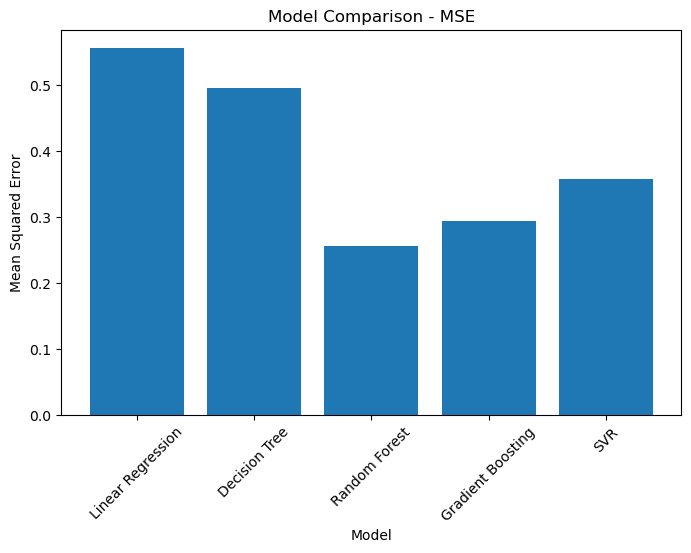

In [48]:
import matplotlib.pyplot as plt

# Plot MSE
plt.figure(figsize=(8, 5))
plt.bar(results["Model"], results["MSE"])
plt.title("Model Comparison - MSE")
plt.xlabel("Model")
plt.ylabel("Mean Squared Error")
plt.xticks(rotation=45)
plt.show()

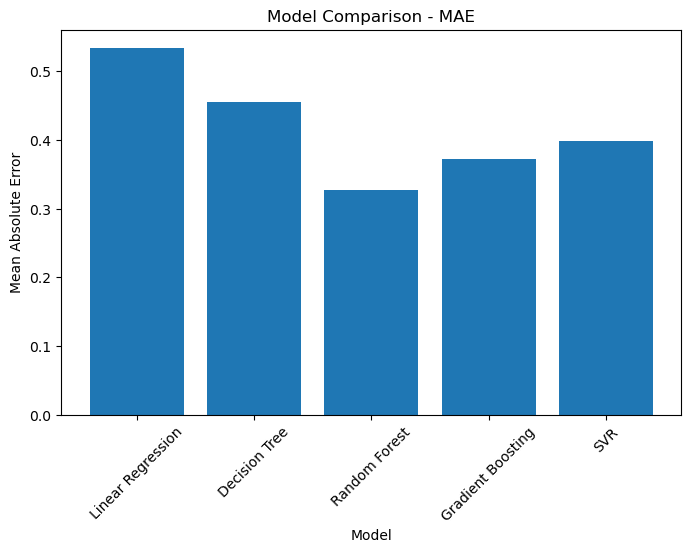

In [49]:
plt.figure(figsize=(8, 5))
plt.bar(results["Model"], results["MAE"])
plt.title("Model Comparison - MAE")
plt.xlabel("Model")
plt.ylabel("Mean Absolute Error")
plt.xticks(rotation=45)
plt.show()

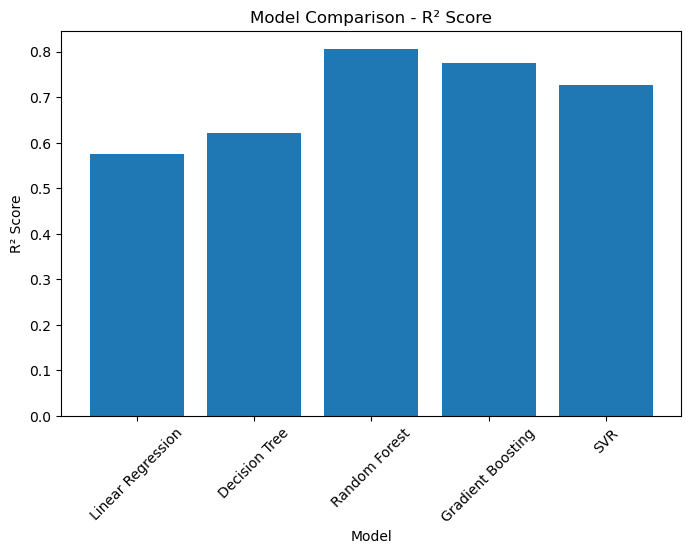

In [50]:
plt.figure(figsize=(8, 5))
plt.bar(results["Model"], results["R2"])
plt.title("Model Comparison - R² Score")
plt.xlabel("Model")
plt.ylabel("R² Score")
plt.xticks(rotation=45)
plt.show()

# Best Performing Model

Based on the evaluation metrics, the **Random Forest Regressor** is the best-performing model among the five regression algorithms.

It achieved the lowest MSE (**0.2554**) and MAE (**0.3275**), while also obtaining the highest R² score (**0.8051**). This indicates that Random Forest provides more accurate predictions and explains approximately **80.51% of the variation** in house values on the test dataset.

The strong performance of Random Forest can be attributed to its ability to capture nonlinear relationships and interactions between features by combining predictions from multiple decision trees.

# Worst Performing Model

The **Linear Regression** model performed the worst among the five models. It produced the highest MSE (**0.5559**) and MAE (**0.5332**) and the lowest R² score (**0.5758**).

This indicates that a simple linear relationship is not sufficient to capture the complex relationships between the housing features and median house values in the California Housing dataset.


## Conclusion

In this assignment, five supervised regression algorithms were implemented and evaluated using the California Housing dataset: Linear Regression, Decision Tree Regressor, Random Forest Regressor, Gradient Boosting Regressor, and Support Vector Regressor (SVR).

The models were evaluated using Mean Squared Error (MSE), Mean Absolute Error (MAE), and R² score. Among the five models, **Random Forest Regressor achieved the best overall performance**, with an MSE of 0.2554, MAE of 0.3275, and R² score of 0.8051. Linear Regression showed the weakest performance, indicating that the dataset contains nonlinear relationships that are better captured by more flexible regression algorithms.

Overall, the results demonstrate that ensemble-based models, particularly Random Forest, can provide more accurate predictions for this housing dataset than a simple linear regression approach.
